## Step 1: Initialize Document Conversion Pipeline

Set up a Docling PDF pipeline with page image generation enabled. The `PdfPipelineOptions` will be configured to create high-quality page images at 2x scale for each page during conversion.

In [2]:
!pip install docling groq google-generativeai

  Using cached docling-2.81.0-py3-none-any.whl.metadata (12 kB)
  Using cached google_generativeai-0.8.6-py3-none-any.whl.metadata (3.9 kB)
  Using cached docling_core-2.70.2-py3-none-any.whl.metadata (8.1 kB)
  Using cached docling_parse-5.6.0-cp312-cp312-win_amd64.whl.metadata (10 kB)
  Using cached docling_ibm_models-3.12.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached pypdfium2-5.6.0-py3-none-win_amd64.whl.metadata (68 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached rapidocr-3.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached rtree-1.4.1-py3-none-win_amd64.whl.metadata (2.2 kB)
  Using cached typer-0.21.2-py3-none-any.whl.metadata (16 kB)
  Using cached python_docx-1.2.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached python_pptx-1.0.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached marko-


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption
from IPython.display import display
import json
import pandas as pd

c:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os

# 1. Disable the symlink warning and the feature itself
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_EXPERIMENTAL_SYMLINKS"] = "1"

# 2. (Optional but recommended) Set a specific cache folder if needed
# os.environ["HUGGINGFACE_HUB_CACHE"] = r"C:\Users\ADmiN\.cache\huggingface"

print("✅ Symlinks disabled. You can now run Docling without Developer Mode.")

✅ Symlinks disabled. You can now run Docling without Developer Mode.


In [5]:
# 1. Define PDF conversion options
pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = 2
pipeline_options.generate_page_images = True

# 2. Initialize the converter with these options
doc_converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
)

# 3. Run the conversion
source = "./docs/DoclingTechnicalReport.pdf"
result = doc_converter.convert(source)
doc = result.document


[INFO] 2026-03-24 00:07:40,240 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-24 00:07:40,276 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-24 00:07:40,278 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-24 00:07:40,632 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-24 00:07:40,639 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-24 00:07:40,641 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-24 00:07:40,807 [RapidOCR] base.py:

## Step 2: Examine Document Metadata

Inspect basic statistics about the converted document to understand its composition and complexity.

In [6]:
print('The number of pages are: ', len(doc.pages))
print('The number of tables are: ', len(doc.tables))
print('The number of pictures are: ', len(doc.pictures))

The number of pages are:  9
The number of tables are:  3
The number of pictures are:  5


## Step 3: Extract and Review Markdown Representation

Export the document as markdown to see the structured text output. This representation captures the document's content in a machine-readable format suitable for analysis or AI processing.

In [7]:
print(doc.export_to_markdown())

<!-- image -->

## Docling Technical Report

## Version 1.0

Christoph Auer Maksym Lysak Ahmed Nassar Michele Dolfi Nikolaos Livathinos Panos Vagenas Cesar Berrospi Ramis Matteo Omenetti Fabian Lindlbauer Kasper Dinkla Lokesh Mishra Yusik Kim Shubham Gupta Rafael Teixeira de Lima Valery Weber Lucas Morin Ingmar Meijer Viktor Kuropiatnyk Peter W. J. Staar

AI4K Group, IBM Research R¨ uschlikon, Switzerland

## Abstract

This technical report introduces Docling , an easy to use, self-contained, MITlicensed open-source package for PDF document conversion. It is powered by state-of-the-art specialized AI models for layout analysis (DocLayNet) and table structure recognition (TableFormer), and runs efficiently on commodity hardware in a small resource budget. The code interface allows for easy extensibility and addition of new features and models.

## 1 Introduction

Converting PDF documents back into a machine-processable format has been a major challenge for decades due to their huge vari

## Step 4: View Page as Image

Render the document page as a visual image to assess the quality and completeness of the page image extraction. This demonstrates an alternative representation that preserves visual layout and formatting.

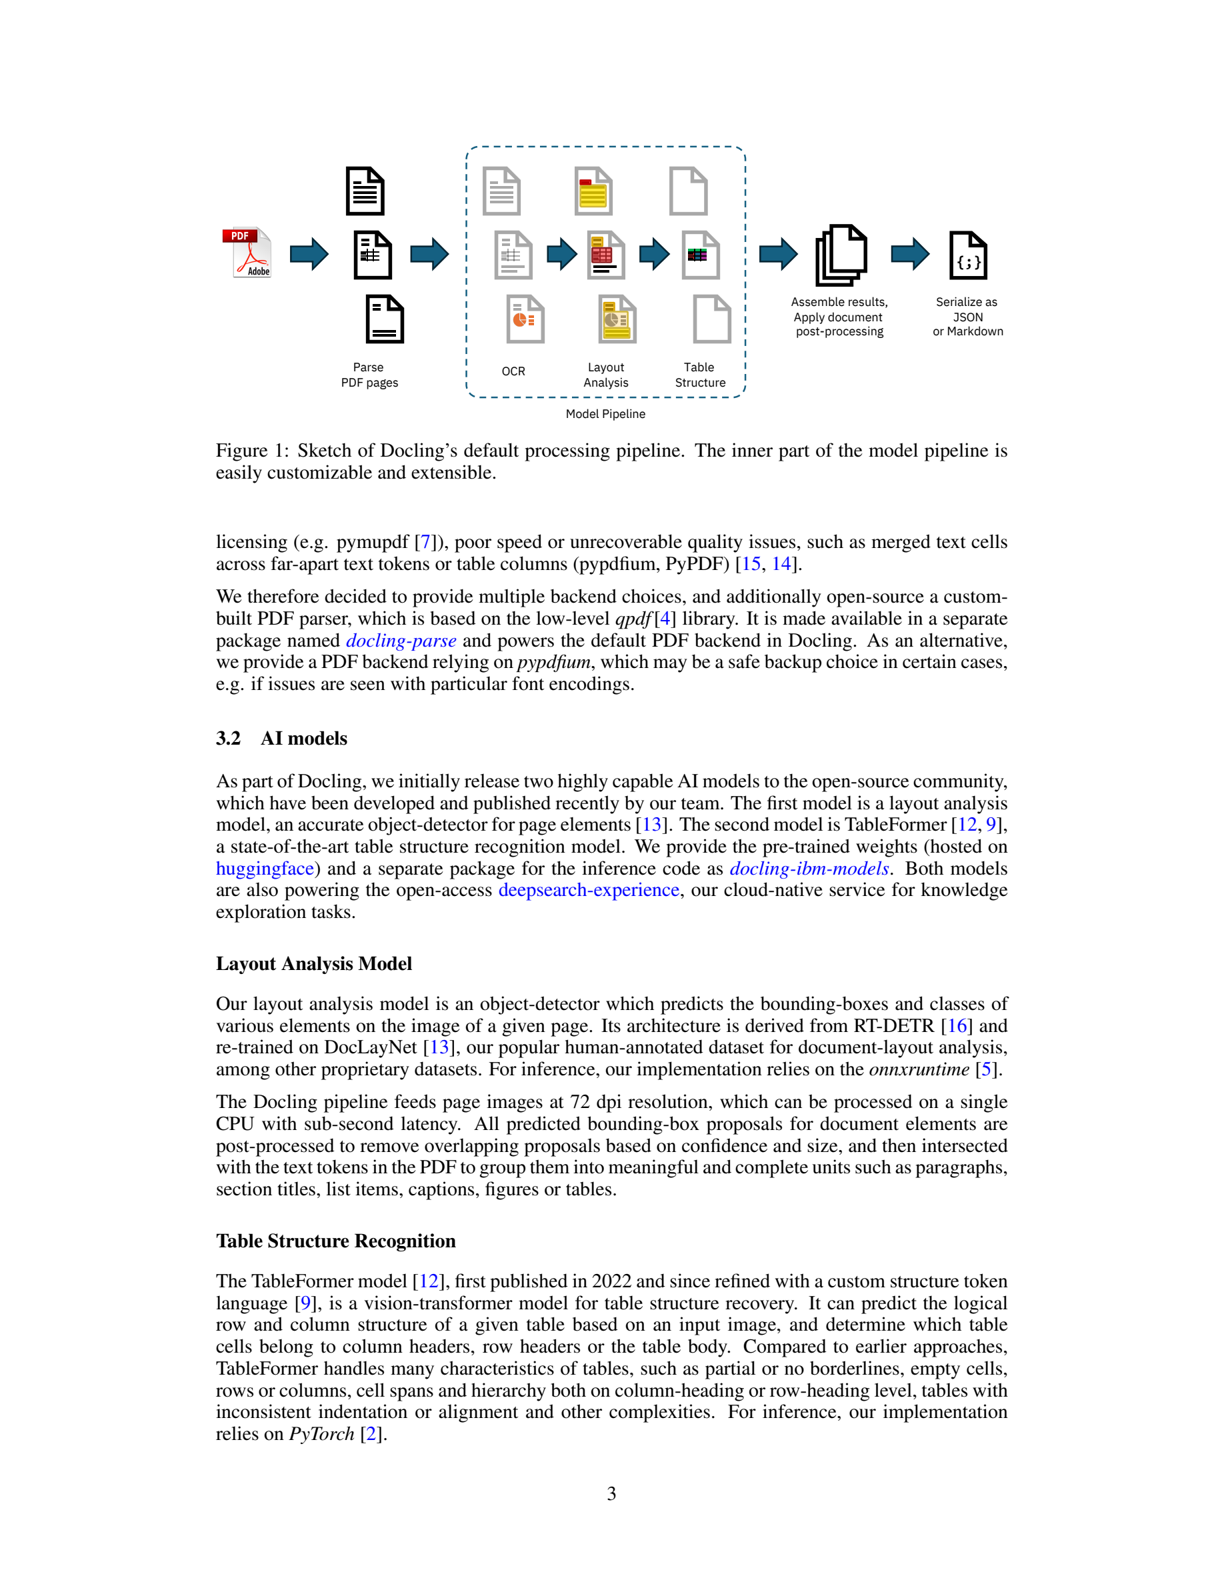

In [8]:
display(doc.pages[3].image.pil_image)

## Step 5: Extract and Display Embedded Images

Extract embedded images from the document to evaluate their relevance and utility for downstream processing pipelines.

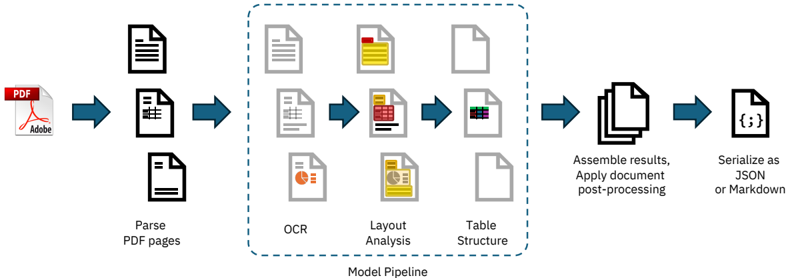

In [9]:
image = doc.pictures[1].get_image(doc = doc)
display(image)

## Step 6: Extract Tables as Structured Data

Convert document tables into pandas DataFrames to evaluate whether table structures are standardized and suitable for direct automated processing without AI intervention.

In [10]:

table_df = doc.tables[0].export_to_dataframe(doc=doc)
table_df

,CPU.,Thread budget.,native backend.TTS,native backend.Pages/s,native backend.Mem,pypdfium backend.TTS,pypdfium backend.Pages/s,pypdfium backend.Mem
0,Apple M3 Max (16 cores),4 16,177 s 167 s,1.27 1.34,6.20 GB,103 s 92 s,2.18 2.45,2.56 GB
1,Intel(R) Xeon E5-2690,4 16,375 s 244 s,0.60 0.92,6.16 GB,239 s 143 s,0.94 1.57,2.42 GB


## Step 7: Serialize Document to JSON

Export the complete parsed document as a serialized JSON file for persistence and reuse. This allows future processing without re-running the expensive document conversion pipeline, enabling auditing, alternative analyses, and cached access to the document structure.

In [11]:
doc_dict = doc.export_to_dict()

In [12]:
with open("document_serialized.json", "w", encoding="utf-8") as f:
    json.dump(doc_dict, f, ensure_ascii=False, indent=2)

## Step 8: Process JPEG Image File

Next, lets demonstrate document conversion on an alternative image format (JPEG) to test the pipeline's capability with different input types.

In [13]:
source = "./docs/image_invoice.jpg"
result = doc_converter.convert(source)
doc = result.document

[INFO] 2026-03-24 00:19:48,930 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-24 00:19:48,959 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-24 00:19:48,961 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-24 00:19:49,256 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-24 00:19:49,272 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-24 00:19:49,276 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-24 00:19:49,492 [RapidOCR] base.py:

In [14]:
print(doc.export_to_markdown())

## Invoiceno:51109338

Date ofissue:

04/13/2013

## Seller:

Andrews,Kirby andValdez 58861GonzalezPrairie LakeDaniellefurt,IN57228

Taxld:945-82-2137

IBAN:GB75MCRL06841367619257

## ITEMS

|   No. | Description                                                            | Qty   | UM   | Netprice   | Networth   | VAT [%]   | Gross worth   |
|-------|------------------------------------------------------------------------|-------|------|------------|------------|-----------|---------------|
|     1 | CLEARANCE!FastDell Desktop ComputerPCDUALCORE WIND0WS104/8/16GBRAM     | 3,00  | each | 209,00     | 627,00     | 10%       | 689,70        |
|     2 | HPT520ThinClientComputer AMDGX-212JC1.2GHz4GBRAM TESTED!!READBELOW!!   | 5,00  | each | 37,75      | 188,75     | 10%       | 207,63        |
|     3 | gamingpcdesktopcomputer                                                | 1,00  | each | 400,00     | 400,00     | 10%       | 440,00        |
|     4 | 12-Core Gaming Computer DesktopPCTowerA

## Step 9: Process Word Document File

Now lets review the same thing with word docs to ensure that Docling can be used for common Microsoft Office formats as well

In [15]:
source = "./docs/word_invoice.docx"
result = doc_converter.convert(source)
doc = result.document

In [16]:
print(doc.export_to_markdown())

<!-- image -->

INVOICE

**Invoice to:                                                                   Invoice#                            52131**

**Daniel Gallego                                                                          Date   01 / 02 / 2023**

123 Rent  St.,

New York, ST 12345

| Item    |   Quantity | Unit Price   | Total     |
|---------|------------|--------------|-----------|
| House   |          1 | 800$         | 800$      |
| Rent    |          1 | 500$         | 500$      |
| Service |          1 | 90$          | 90$       |
|         |            | Subtotal     | **1567$** |
|         |            | Tax (0%)     | $0        |
|         |            | Total        | **1980$** |

Thank you for your business! **\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_**

<!-- image -->
